In [4]:
import tensorflow_datasets as tfds

print(tfds.__version__)

4.9.9


In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

IMG_SIZE = 224
BATCH_SIZE = 16

(ds_train, ds_val, ds_test), info = tfds.load(
    "tf_flowers",
    split=["train[:70%]", "train[70%:85%]", "train[85%:]"],
    as_supervised=True,
    with_info=True
)

train_np = list(tfds.as_numpy(ds_train))
val_np   = list(tfds.as_numpy(ds_val))
test_np  = list(tfds.as_numpy(ds_test))

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class FlowersDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image, label = self.data[idx]
        image = Image.fromarray(image)

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

ds_train = DataLoader(
    FlowersDataset(train_np, transform),
    batch_size=BATCH_SIZE,
    shuffle=True
)

ds_val = DataLoader(
    FlowersDataset(val_np, transform),
    batch_size=BATCH_SIZE,
    shuffle=False
)

ds_test = DataLoader(
    FlowersDataset(test_np, transform),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.TME9RH_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.


In [6]:
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Linear(num_features, 128),
    nn.ReLU(),
    nn.Linear(128, 5)
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 39.9MB/s]


In [7]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

In [8]:
import torch

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

In [19]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=3, patience=2):

    history = {
        "train_acc": [],
        "val_acc": [],
        "train_loss": [],
        "val_loss": []
    }

    best_val_acc = 0
    counter = 0
    best_model_state = None

    for epoch in range(epochs):

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer
        )

        val_loss, val_acc = evaluate(
            model, val_loader, criterion
        )

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"train_acc: {train_acc:.4f}, val_acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict()
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            print("Early stopping")
            break

    model.load_state_dict(best_model_state)

    return history

In [10]:
history = train_model(
    model, ds_train, ds_val, criterion, optimizer, epochs=3
)

Epoch 1/3
train_acc: 0.8622, val_acc: 0.9093
Epoch 2/3
train_acc: 0.8649, val_acc: 0.8820
Epoch 3/3
train_acc: 0.8618, val_acc: 0.9111


<All keys matched successfully>

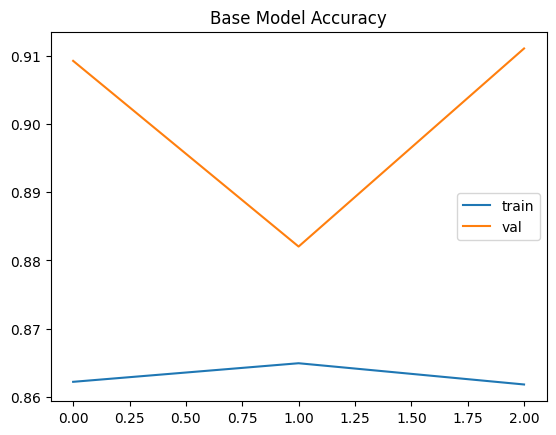

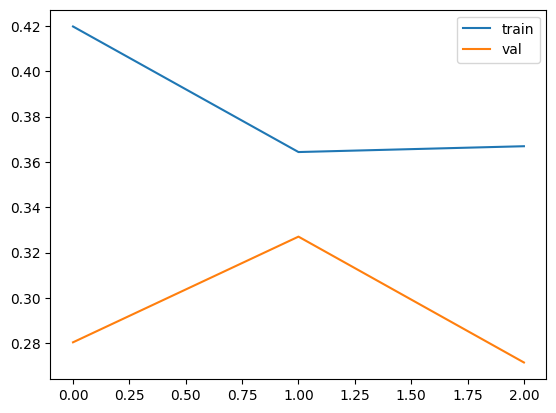

In [12]:
import matplotlib.pyplot as plt

plt.plot(history["train_acc"], label="train")
plt.plot(history["val_acc"], label="val")
plt.title("Base Model Accuracy")
plt.legend()
plt.show()

plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.legend()
plt.show()

In [14]:
test_loss, test_acc = evaluate(model, ds_test, criterion)

print("Test Accuracy:", test_acc)

Test Accuracy: 0.8927272727272727


In [15]:
for param in model.parameters():
    param.requires_grad = True

for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

In [16]:
import torch.optim as optim

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

In [17]:
history_ft = train_model(
    model, ds_train, ds_val, criterion, optimizer, epochs=3
)

Epoch 1/3
train_acc: 0.9081, val_acc: 0.9365
Epoch 2/3
train_acc: 0.9537, val_acc: 0.9437
Epoch 3/3
train_acc: 0.9681, val_acc: 0.9347


<All keys matched successfully>

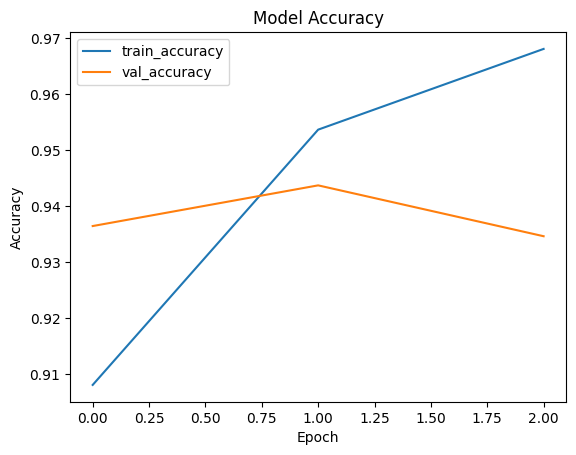

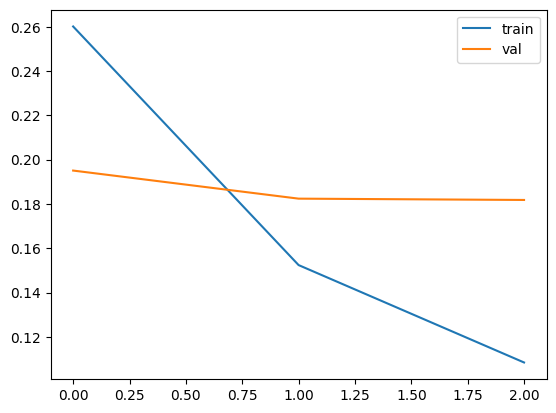

In [18]:

plt.plot(history_ft["train_acc"], label="train_accuracy")
plt.plot(history_ft["val_acc"], label="val_accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(history_ft["train_loss"], label="train")
plt.plot(history_ft["val_loss"], label="val")
plt.legend()
plt.show()

In [20]:
history_ft2 = train_model(
    model, ds_train, ds_val, criterion, optimizer, epochs=3
)

Epoch 1/3
train_acc: 0.9809, val_acc: 0.9437
Epoch 2/3
train_acc: 0.9868, val_acc: 0.9365
Epoch 3/3
train_acc: 0.9922, val_acc: 0.9437
Early stopping


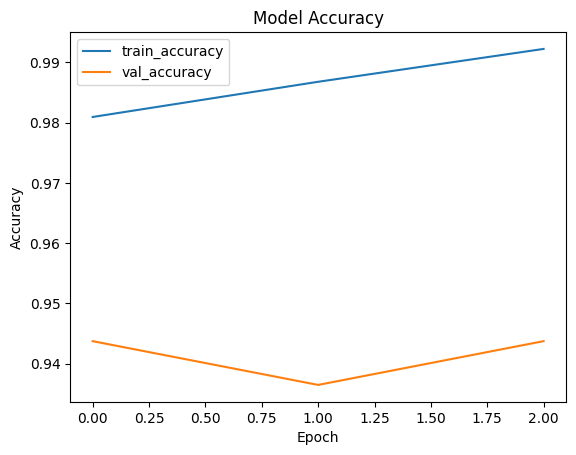

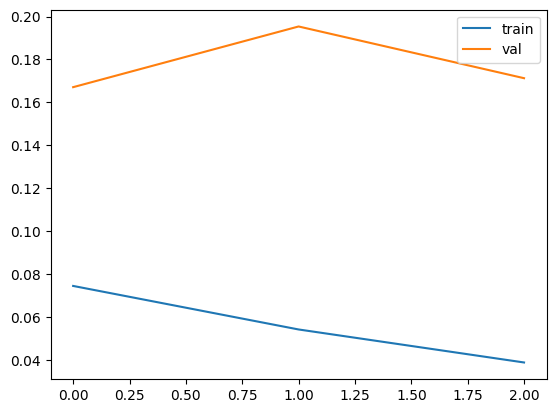

In [22]:
plt.plot(history_ft2["train_acc"], label="train_accuracy")
plt.plot(history_ft2["val_acc"], label="val_accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(history_ft2["train_loss"], label="train")
plt.plot(history_ft2["val_loss"], label="val")
plt.legend()
plt.show()

In [23]:
import time

model.eval()

batch = next(iter(ds_test))[0]  # أخذ batch واحد

batch = batch.to(device)

start = time.time()

with torch.no_grad():
    outputs = model(batch)

end = time.time()

print("Inference time:", end - start)

Inference time: 5.044309854507446
